In [3]:
pip install kafka

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip uninstall -y kafka-python

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install kafka-python-ng

Note: you may need to restart the kernel to use updated packages.


In [1]:
from kafka import KafkaProducer
print("Kafka Python is working")

Kafka Python is working


In [3]:
import json
from kafka import KafkaProducer

producer = KafkaProducer(
    bootstrap_servers="localhost:9092",
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

future = producer.send(
    "sentiment_data",
    {"test": "hello"}
)

future.get(timeout=10)

producer.close()

print("Kafka connection and message test successful")

Kafka connection and message test successful


In [5]:
import subprocess
import json
from kafka import KafkaProducer
import pyarrow.parquet as pq
import pyarrow as pa

HDFS_PATH = "/group4/exorde_dataset/processed_data_10.parquet"
KAFKA_SERVER = "localhost:9092"
TOPIC = "sentiment_data"

producer = KafkaProducer(
    bootstrap_servers=KAFKA_SERVER,
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

print("Kafka producer started.")
print("Reading dataset from HDFS...")

# Copy one Parquet file temporarily from HDFS to local storage
local_file = "processed_data_10.parquet"

subprocess.run(
    [
        r"C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2\bin\hdfs.cmd",
        "dfs",
        "-get",
        HDFS_PATH,
        local_file
    ],
    check=True
)

table = pq.read_table(local_file)

rows = table.to_pylist()

print("Records loaded:", len(rows))

# Send only 100 records for the first test
for row in rows[:100]:
    producer.send(TOPIC, row)

producer.flush()

print("100 records sent successfully to Kafka.")

producer.close()

Kafka producer started.
Reading dataset from HDFS...
Records loaded: 498432
100 records sent successfully to Kafka.


In [7]:
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    "sentiment_data",
    bootstrap_servers="localhost:9092",
    auto_offset_reset="earliest",
    consumer_timeout_ms=5000,
    value_deserializer=lambda x: json.loads(x.decode("utf-8"))
)

count = 0

for message in consumer:
    print(message.value)
    count += 1
    
    if count == 5:
        break

consumer.close()

print("Messages received:", count)

{'test': 'hello'}
{'date': '2024-12-01T09:31:08.000Z', 'original_text': 'I don’t think you understand the meaning of urgent.\n\n$700k in a high yield (not so high anymore) savings is still earning more than what it would have prior to announcement of raising interest rates in 03/2022.\n\nIt’s not like it fell from 5% to 1%, or even 2%.\n\nThat’s to say, you have time and it’s not urgent. \n\nDon’t know what to do with the cash and vested rsu? Start with the wiki (sidebar) and possibly consult with a really good cpa. Not enough information and quite possibly more of a circle jerk post than anything.', 'url': 'https://www.reddit.com/r/personalfinance/comments/1h3zhjm/advice_on_these_2_urgent_decisions_to_make/lzukqt7/', 'author_hash': None, 'language': 'en', 'primary_theme': 'Economy', 'english_keywords': 'meaning, raising interest, urgent, yield, anymore, high anymore, announcement, rates, vested, raising, fell, high, interest, not, rsu, start, high yield, interest rates, understand, si

In [9]:
from kafka import KafkaConsumer

consumer = KafkaConsumer(
    "sentiment_data",
    bootstrap_servers="localhost:9092",
    auto_offset_reset="earliest",
    consumer_timeout_ms=5000
)

count = 0

for message in consumer:
    count += 1

consumer.close()

print("Total messages in Kafka:", count)

Total messages in Kafka: 101


In [13]:
pip install pyspark

     ---------------------------------------- 0.0/450.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/450.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/450.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/450.1 MB ? eta -:--:--
     ---------------------------------------- 0.3/450.1 MB ? eta -:--:--
     ---------------------------------------- 0.3/450.1 MB ? eta -:--:--
     -------------------------------------- 0.8/450.1 MB 907.1 kB/s eta 0:08:16
     ---------------------------------------- 1.3/450.1 MB 1.4 MB/s eta 0:05:22
     ---------------------------------------- 2.6/450.1 MB 2.4 MB/s eta 0:03:07
     ---------------------------------------- 2.9/450.1 MB 2.5 MB/s eta 0:02:59
      --------------------------------------- 6.6/450.1 MB 4.5 MB/s eta 0:01:40
      --------------------------------------- 8.4/450.1 MB 5.0 MB/s eta 0:01:29
      -------------------------------------- 10.0/450.1 MB 5.3 MB/s eta 0:01:24
  

In [17]:
import os
import shutil

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("Java found:", shutil.which("java"))

JAVA_HOME: C:\Java\Jdk
Java found: C:\Program Files (x86)\Common Files\Oracle\Java\javapath\java.EXE


In [19]:
import os

os.environ["JAVA_HOME"] = r"C:\Progra~1\Java\jdk-17.0.5"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

print("JAVA_HOME:", os.environ["JAVA_HOME"])

JAVA_HOME: C:\Progra~1\Java\jdk-17.0.5


In [21]:
import subprocess

result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True
)

print(result.stderr)

java version "17.0.5" 2022-10-18 LTS
Java(TM) SE Runtime Environment (build 17.0.5+9-LTS-191)
Java HotSpot(TM) 64-Bit Server VM (build 17.0.5+9-LTS-191, mixed mode, sharing)



In [27]:
import shutil
import os

print("spark-submit:", shutil.which("spark-submit"))
print("SPARK_HOME:", os.environ.get("SPARK_HOME"))

spark-submit: C:\Users\user\anaconda3\Scripts\spark-submit.CMD
SPARK_HOME: C:\spark


In [29]:
import os

print("spark-submit.cmd:", os.path.exists(r"C:\spark\bin\spark-submit.cmd"))
print("spark-class.cmd:", os.path.exists(r"C:\spark\bin\spark-class.cmd"))
print("Spark folder:", os.path.exists(r"C:\spark"))

spark-submit.cmd: False
spark-class.cmd: False
Spark folder: False


In [31]:
import pyspark
import os

print("PySpark location:")
print(os.path.dirname(pyspark.__file__))

print("\nPySpark version:")
print(pyspark.__version__)

PySpark location:
C:\Users\user\anaconda3\envs\ahs2024\Lib\site-packages\pyspark

PySpark version:
4.2.0


In [33]:
import os

os.environ.pop("SPARK_HOME", None)

print("SPARK_HOME:", os.environ.get("SPARK_HOME"))

SPARK_HOME: None


In [35]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark is working")

Spark version: 4.2.0
Spark is working


In [37]:
df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "sentiment_data") \
    .option("startingOffsets", "earliest") \
    .load()

print("Spark connected to Kafka")
df.printSchema()

AnalysisException: Failed to find data source: kafka. Please deploy the application as per the deployment section of Structured Streaming + Kafka Integration Guide.

In [39]:
spark.stop()

In [41]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config(
        "spark.jars.packages",
        "org.apache.spark:spark-sql-kafka-0-10_2.13:4.2.0"
    ) \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark with Kafka connector is working")

Spark version: 4.2.0
Spark with Kafka connector is working


In [43]:
df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "sentiment_data") \
    .option("startingOffsets", "earliest") \
    .load()

print("Spark connected to Kafka")
df.printSchema()

AnalysisException: Failed to find data source: kafka. Please deploy the application as per the deployment section of Structured Streaming + Kafka Integration Guide.

In [45]:
print(
    spark.sparkContext.getConf().get("spark.jars.packages", "NOT SET")
)

print(
    spark.sparkContext.getConf().get("spark.jars", "NO JARS")
)

org.apache.spark:spark-sql-kafka-0-10_2.13:4.2.0
NO JARS


In [48]:
import os

ivy_path = os.path.expanduser("~/.ivy2/jars")

print("Ivy folder exists:", os.path.exists(ivy_path))

if os.path.exists(ivy_path):
    print("\nDownloaded Spark packages:")
    for file in os.listdir(ivy_path):
        print(file)

Ivy folder exists: False


In [50]:
import os
import pyspark

pyspark_path = os.path.dirname(pyspark.__file__)

matches = []

for root, dirs, files in os.walk(pyspark_path):
    for file in files:
        if "kafka" in file.lower() and file.endswith(".jar"):
            matches.append(os.path.join(root, file))

print("Kafka JARs found:", len(matches))

for file in matches:
    print(file)

Kafka JARs found: 0


In [52]:
import urllib.request

url = "https://repo1.maven.org/maven2/org/apache/spark/spark-sql-kafka-0-10_2.13/4.2.0/spark-sql-kafka-0-10_2.13-4.2.0.jar"

try:
    response = urllib.request.urlopen(url, timeout=10)
    print("Internet access: OK")
    print("Kafka connector available:", response.status == 200)
except Exception as e:
    print("Download test failed:")
    print(e)

Internet access: OK
Kafka connector available: True


In [54]:
import urllib.request
import os

url = "https://repo1.maven.org/maven2/org/apache/spark/spark-sql-kafka-0-10_2.13/4.2.0/spark-sql-kafka-0-10_2.13-4.2.0.jar"

jar_path = os.path.join(os.getcwd(), "spark-sql-kafka-0-10_2.13-4.2.0.jar")

urllib.request.urlretrieve(url, jar_path)

print("Downloaded:", os.path.exists(jar_path))
print("File:", jar_path)
print("Size:", os.path.getsize(jar_path), "bytes")

Downloaded: True
File: C:\Users\user\OneDrive\Desktop\Group4_Sentiment_Analysis\spark-sql-kafka-0-10_2.13-4.2.0.jar
Size: 494879 bytes


In [56]:
import os
from pyspark.sql import SparkSession

jar_path = os.path.join(
    os.getcwd(),
    "spark-sql-kafka-0-10_2.13-4.2.0.jar"
)

spark.stop()

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config("spark.jars", jar_path) \
    .getOrCreate()

print("Spark restarted")
print("Kafka JAR:", jar_path)

Py4JJavaError: An error occurred while calling None.org.apache.spark.api.java.JavaSparkContext.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: Hadoop home directory C:\hadoop does not exist -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems
	at org.apache.hadoop.util.Shell.getWinUtilsPath(Shell.java:790)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:299)
	at org.apache.hadoop.fs.FileUtil.chmod(FileUtil.java:1305)
	at org.apache.hadoop.fs.FileUtil.chmod(FileUtil.java:1291)
	at org.apache.spark.util.Utils$.fetchFile(Utils.scala:432)
	at org.apache.spark.executor.Executor.$anonfun$updateDependencies$14(Executor.scala:1489)
	at org.apache.spark.executor.Executor.$anonfun$updateDependencies$14$adapted(Executor.scala:1480)
	at scala.collection.IterableOnceOps.foreach(IterableOnce.scala:630)
	at scala.collection.IterableOnceOps.foreach$(IterableOnce.scala:628)
	at scala.collection.AbstractIterab

In [58]:
import os

HADOOP_HOME = r"C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2"

os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["PATH"] = HADOOP_HOME + r"\bin;" + HADOOP_HOME + r"\sbin;" + os.environ["PATH"]

print("HADOOP_HOME:", os.environ["HADOOP_HOME"])
print("winutils exists:", os.path.exists(HADOOP_HOME + r"\bin\winutils.exe"))

HADOOP_HOME: C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2
winutils exists: True


In [60]:
from pyspark.sql import SparkSession
import os

jar_path = os.path.join(
    os.getcwd(),
    "spark-sql-kafka-0-10_2.13-4.2.0.jar"
)

spark.stop()

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config("spark.jars", jar_path) \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark with Kafka JAR is working")

Py4JJavaError: An error occurred while calling None.org.apache.spark.api.java.JavaSparkContext.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: Hadoop home directory C:\hadoop does not exist -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems
	at org.apache.hadoop.util.Shell.getWinUtilsPath(Shell.java:790)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:299)
	at org.apache.hadoop.fs.FileUtil.chmod(FileUtil.java:1305)
	at org.apache.hadoop.fs.FileUtil.chmod(FileUtil.java:1291)
	at org.apache.spark.util.Utils$.fetchFile(Utils.scala:432)
	at org.apache.spark.executor.Executor.$anonfun$updateDependencies$14(Executor.scala:1489)
	at org.apache.spark.executor.Executor.$anonfun$updateDependencies$14$adapted(Executor.scala:1480)
	at scala.collection.IterableOnceOps.foreach(IterableOnce.scala:630)
	at scala.collection.IterableOnceOps.foreach$(IterableOnce.scala:628)
	at scala.collection.AbstractIterab

In [1]:
import os

os.environ["JAVA_HOME"] = r"C:\Progra~1\Java\jdk-17.0.5"

os.environ["HADOOP_HOME"] = (
    r"C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2"
)

os.environ["HADOOP_HOME_DIR"] = os.environ["HADOOP_HOME"]

os.environ["PATH"] = (
    os.environ["JAVA_HOME"] + r"\bin;"
    + os.environ["HADOOP_HOME"] + r"\bin;"
    + os.environ["HADOOP_HOME"] + r"\sbin;"
    + os.environ["PATH"]
)

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("HADOOP_HOME:", os.environ["HADOOP_HOME"])
print(
    "winutils:",
    os.path.exists(
        os.environ["HADOOP_HOME"] + r"\bin\winutils.exe"
    )
)

JAVA_HOME: C:\Progra~1\Java\jdk-17.0.5
HADOOP_HOME: C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2
winutils: True


In [3]:
from pyspark.sql import SparkSession
import os

jar_path = os.path.join(
    os.getcwd(),
    "spark-sql-kafka-0-10_2.13-4.2.0.jar"
)

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config("spark.jars", jar_path) \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark with Kafka JAR is working")

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [5]:
import os
import shutil

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("Java:", shutil.which("java"))
print("Spark-submit:", shutil.which("spark-submit"))
print("SPARK_HOME:", os.environ.get("SPARK_HOME"))

JAVA_HOME: C:\Progra~1\Java\jdk-17.0.5
Java: C:\Progra~1\Java\jdk-17.0.5\bin\java.EXE
Spark-submit: C:\Users\user\anaconda3\Scripts\spark-submit.CMD
SPARK_HOME: C:\spark


In [7]:
import os
import pyspark

pyspark_path = os.path.dirname(pyspark.__file__)

print("PySpark:", pyspark_path)
print(
    "Spark submit:",
    os.path.exists(os.path.join(pyspark_path, "bin", "spark-submit.cmd"))
)
print(
    "Spark class:",
    os.path.exists(os.path.join(pyspark_path, "bin", "spark-class.cmd"))
)

PySpark: C:\Users\user\anaconda3\envs\ahs2024\Lib\site-packages\pyspark
Spark submit: True
Spark class: True


In [9]:
import os
import pyspark

SPARK_HOME = os.path.dirname(pyspark.__file__)

os.environ["SPARK_HOME"] = SPARK_HOME

# Put the correct Spark bin first
os.environ["PATH"] = (
    SPARK_HOME + r"\bin;"
    + os.environ["PATH"]
)

print("SPARK_HOME:", os.environ["SPARK_HOME"])
print(
    "Correct spark-submit:",
    os.path.exists(SPARK_HOME + r"\bin\spark-submit.cmd")
)

SPARK_HOME: C:\Users\user\anaconda3\envs\ahs2024\Lib\site-packages\pyspark
Correct spark-submit: True


In [11]:
from pyspark.sql import SparkSession
import os

jar_path = os.path.join(
    os.getcwd(),
    "spark-sql-kafka-0-10_2.13-4.2.0.jar"
)

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config("spark.jars", jar_path) \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark with Kafka JAR is working")

Spark version: 4.2.0
Spark with Kafka JAR is working


In [13]:
df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "sentiment_data") \
    .option("startingOffsets", "earliest") \
    .load()

print("Spark connected to Kafka")
df.printSchema()

Py4JJavaError: An error occurred while calling o36.load.
: java.lang.NoClassDefFoundError: org/apache/kafka/common/serialization/ByteArraySerializer
	at org.apache.spark.sql.kafka010.KafkaSourceProvider$.<clinit>(KafkaSourceProvider.scala:613)
	at org.apache.spark.sql.kafka010.KafkaSourceProvider.org$apache$spark$sql$kafka010$KafkaSourceProvider$$validateStreamOptions(KafkaSourceProvider.scala:352)
	at org.apache.spark.sql.kafka010.KafkaSourceProvider.sourceSchema(KafkaSourceProvider.scala:73)
	at org.apache.spark.sql.execution.datasources.DataSource.sourceSchema(DataSource.scala:254)
	at org.apache.spark.sql.execution.datasources.DataSource.sourceInfo$lzycompute(DataSource.scala:139)
	at org.apache.spark.sql.execution.datasources.DataSource.sourceInfo(DataSource.scala:139)
	at org.apache.spark.sql.execution.streaming.runtime.StreamingRelation$.apply(StreamingRelation.scala:40)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource$$anonfun$apply$1.applyOrElse(ResolveData

In [15]:
import urllib.request
import os

url = "https://repo1.maven.org/maven2/org/apache/kafka/kafka-clients/3.9.2/kafka-clients-3.9.2.jar"

jar_path = os.path.join(
    os.getcwd(),
    "kafka-clients-3.9.2.jar"
)

urllib.request.urlretrieve(url, jar_path)

print("Downloaded:", os.path.exists(jar_path))
print("File:", jar_path)
print("Size:", os.path.getsize(jar_path), "bytes")

Downloaded: True
File: C:\Users\user\OneDrive\Desktop\Group4_Sentiment_Analysis\kafka-clients-3.9.2.jar
Size: 9220052 bytes


In [17]:
import urllib.request
import os

url = "https://repo1.maven.org/maven2/org/apache/spark/spark-token-provider-kafka-0-10_2.13/4.2.0/spark-token-provider-kafka-0-10_2.13-4.2.0.jar"

jar_path = os.path.join(
    os.getcwd(),
    "spark-token-provider-kafka-0-10_2.13-4.2.0.jar"
)

urllib.request.urlretrieve(url, jar_path)

print("Downloaded:", os.path.exists(jar_path))
print("File:", jar_path)
print("Size:", os.path.getsize(jar_path), "bytes")

Downloaded: True
File: C:\Users\user\OneDrive\Desktop\Group4_Sentiment_Analysis\spark-token-provider-kafka-0-10_2.13-4.2.0.jar
Size: 66617 bytes


In [19]:
import urllib.request
import os

url = "https://repo1.maven.org/maven2/org/scala-lang/modules/scala-parallel-collections_2.13/1.2.0/scala-parallel-collections_2.13-1.2.0.jar"

jar_path = os.path.join(
    os.getcwd(),
    "scala-parallel-collections_2.13-1.2.0.jar"
)

urllib.request.urlretrieve(url, jar_path)

print("Downloaded:", os.path.exists(jar_path))
print("File:", jar_path)
print("Size:", os.path.getsize(jar_path), "bytes")

Downloaded: True
File: C:\Users\user\OneDrive\Desktop\Group4_Sentiment_Analysis\scala-parallel-collections_2.13-1.2.0.jar
Size: 1120803 bytes


In [21]:
import urllib.request
import os

url = "https://repo1.maven.org/maven2/com/google/code/findbugs/jsr305/3.0.0/jsr305-3.0.0.jar"

jar_path = os.path.join(
    os.getcwd(),
    "jsr305-3.0.0.jar"
)

urllib.request.urlretrieve(url, jar_path)

print("Downloaded:", os.path.exists(jar_path))
print("File:", jar_path)
print("Size:", os.path.getsize(jar_path), "bytes")

Downloaded: True
File: C:\Users\user\OneDrive\Desktop\Group4_Sentiment_Analysis\jsr305-3.0.0.jar
Size: 33031 bytes


In [23]:
import urllib.request
import os

url = "https://repo1.maven.org/maven2/org/apache/commons/commons-pool2/2.13.1/commons-pool2-2.13.1.jar"

jar_path = os.path.join(
    os.getcwd(),
    "commons-pool2-2.13.1.jar"
)

urllib.request.urlretrieve(url, jar_path)

print("Downloaded:", os.path.exists(jar_path))
print("File:", jar_path)
print("Size:", os.path.getsize(jar_path), "bytes")

Downloaded: True
File: C:\Users\user\OneDrive\Desktop\Group4_Sentiment_Analysis\commons-pool2-2.13.1.jar
Size: 156457 bytes


In [1]:
import os
import pyspark

os.environ["JAVA_HOME"] = r"C:\Progra~1\Java\jdk-17.0.5"

os.environ["HADOOP_HOME"] = (
    r"C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2"
)

os.environ["HADOOP_HOME_DIR"] = os.environ["HADOOP_HOME"]

SPARK_HOME = os.path.dirname(pyspark.__file__)
os.environ["SPARK_HOME"] = SPARK_HOME

os.environ["PATH"] = (
    os.environ["JAVA_HOME"] + r"\bin;"
    + os.environ["HADOOP_HOME"] + r"\bin;"
    + os.environ["HADOOP_HOME"] + r"\sbin;"
    + SPARK_HOME + r"\bin;"
    + os.environ["PATH"]
)

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("HADOOP_HOME:", os.environ["HADOOP_HOME"])
print("SPARK_HOME:", os.environ["SPARK_HOME"])

JAVA_HOME: C:\Progra~1\Java\jdk-17.0.5
HADOOP_HOME: C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2
SPARK_HOME: C:\Users\user\anaconda3\envs\ahs2024\Lib\site-packages\pyspark


In [4]:
import os
from pyspark.sql import SparkSession

project_dir = os.getcwd()

jars = [
    os.path.join(project_dir, "spark-sql-kafka-0-10_2.13-4.2.0.jar"),
    os.path.join(project_dir, "kafka-clients-3.9.2.jar"),
    os.path.join(project_dir, "spark-token-provider-kafka-0-10_2.13-4.2.0.jar"),
    os.path.join(project_dir, "scala-parallel-collections_2.13-1.2.0.jar"),
    os.path.join(project_dir, "jsr305-3.0.0.jar"),
    os.path.join(project_dir, "commons-pool2-2.13.1.jar")
]

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config("spark.jars", ",".join(jars)) \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark started successfully")

Spark version: 4.2.0
Spark started successfully


In [6]:
df = spark.read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "sentiment_data") \
    .option("startingOffsets", "earliest") \
    .load()

print("Kafka connection successful")
print("Number of messages:", df.count())

Kafka connection successful
Number of messages: 101


In [8]:
df.selectExpr(
    "CAST(value AS STRING) AS value"
).show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import (
    StructType, StructField, StringType,
    DoubleType, ArrayType, IntegerType
)

schema = StructType([
    StructField("date", StringType(), True),
    StructField("original_text", StringType(), True),
    StructField("url", StringType(), True),
    StructField("author_hash", StringType(), True),
    StructField("language", StringType(), True),
    StructField("primary_theme", StringType(), True),
    StructField("english_keywords", StringType(), True),
    StructField("sentiment", DoubleType(), True),
    StructField("main_emotion", StringType(), True),
    StructField("secondary_themes", ArrayType(IntegerType()), True)
])

parsed_df = df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

parsed_df.show(5, truncate=50)

+------------------------+--------------------------------------------------+--------------------------------------------------+-----------+--------+-------------+--------------------------------------------------+---------+------------+----------------+
|                    date|                                     original_text|                                               url|author_hash|language|primary_theme|                                  english_keywords|sentiment|main_emotion|secondary_themes|
+------------------------+--------------------------------------------------+--------------------------------------------------+-----------+--------+-------------+--------------------------------------------------+---------+------------+----------------+
|                    NULL|                                              NULL|                                              NULL|       NULL|    NULL|         NULL|                                              NULL|     NULL|        NUL

In [12]:
clean_df = parsed_df.filter(
    col("sentiment").isNotNull()
)

print("Valid records:", clean_df.count())
clean_df.show(5, truncate=50)

Valid records: 100
+------------------------+--------------------------------------------------+--------------------------------------------------+-----------+--------+-------------+--------------------------------------------------+---------+------------+----------------+
|                    date|                                     original_text|                                               url|author_hash|language|primary_theme|                                  english_keywords|sentiment|main_emotion|secondary_themes|
+------------------------+--------------------------------------------------+--------------------------------------------------+-----------+--------+-------------+--------------------------------------------------+---------+------------+----------------+
|2024-12-01T09:31:08.000Z|I don’t think you understand the meaning of urg...|https://www.reddit.com/r/personalfinance/commen...|       NULL|      en|      Economy|meaning, raising interest, urgent, yield, anymo...|  

In [14]:
from pyspark.sql.functions import when

labeled_df = clean_df.withColumn(
    "sentiment_label",
    when(col("sentiment") < 0, "Negative")
    .otherwise("Positive")
)

labeled_df.select(
    "sentiment",
    "sentiment_label"
).show(20)

+---------+---------------+
|sentiment|sentiment_label|
+---------+---------------+
|     0.58|       Positive|
|     0.02|       Positive|
|      0.5|       Positive|
|    -0.33|       Negative|
|     0.42|       Positive|
|    -0.31|       Negative|
|    -0.07|       Negative|
|    -0.46|       Negative|
|     0.74|       Positive|
|     0.16|       Positive|
|     0.42|       Positive|
|     -0.5|       Negative|
|     0.19|       Positive|
|     -0.5|       Negative|
|     0.17|       Positive|
|      0.7|       Positive|
|     0.02|       Positive|
|    -0.45|       Negative|
|     0.54|       Positive|
|     0.75|       Positive|
+---------+---------------+
only showing top 20 rows


In [16]:
labeled_df.groupBy("sentiment_label").count().show()

+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|       Positive|   62|
|       Negative|   38|
+---------------+-----+



In [18]:
from pyspark.sql.functions import count, lit

total = labeled_df.count()

distribution = labeled_df.groupBy("sentiment_label") \
    .count() \
    .withColumn(
        "percentage",
        (col("count") / lit(total) * 100)
    )

distribution.show()

+---------------+-----+----------+
|sentiment_label|count|percentage|
+---------------+-----+----------+
|       Positive|   62|      62.0|
|       Negative|   38|      38.0|
+---------------+-----+----------+



In [20]:
labeled_df.select(
    "original_text",
    "sentiment_label"
).show(10, truncate=100)

+----------------------------------------------------------------------------------------------------+---------------+
|                                                                                       original_text|sentiment_label|
+----------------------------------------------------------------------------------------------------+---------------+
|I don’t think you understand the meaning of urgent.\n\n$700k in a high yield (not so high anymore...|       Positive|
|IIwy I will test it "the leniency" by talking about a friend who married someone without a degree...|       Positive|
|                                                                         Piper Cait would be so cool|       Positive|
|If you want “proper help” go to a doctor. And I’m not “dismissing” it as stress, to me that looks...|       Negative|
|                                                                                           Sahten 🥰|       Positive|
|> However P3's will circle for days...crew rest?

In [22]:
train_df, test_df = labeled_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 83
Testing records: 17


In [24]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

tokenizer = Tokenizer(
    inputCol="original_text",
    outputCol="words"
)

hashingTF = HashingTF(
    inputCol="words",
    outputCol="rawFeatures",
    numFeatures=10000
)

idf = IDF(
    inputCol="rawFeatures",
    outputCol="features"
)

print("TF-IDF components created successfully")

TF-IDF components created successfully


In [26]:
train_words = tokenizer.transform(train_df)
test_words = tokenizer.transform(test_df)

train_tf = hashingTF.transform(train_words)
test_tf = hashingTF.transform(test_words)

idf_model = idf.fit(train_tf)

train_features = idf_model.transform(train_tf)
test_features = idf_model.transform(test_tf)

print("TF-IDF transformation completed successfully")

TF-IDF transformation completed successfully


In [28]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="sentiment_label",
    outputCol="label"
)

train_labeled = label_indexer.fit(train_features).transform(train_features)
test_labeled = label_indexer.fit(train_features).transform(test_features)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

lr_model = lr.fit(train_labeled)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [30]:
predictions = lr_model.transform(test_labeled)

predictions.select(
    "sentiment_label",
    "label",
    "prediction"
).show(17)

+---------------+-----+----------+
|sentiment_label|label|prediction|
+---------------+-----+----------+
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       1.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       0.0|
|       Positive|  0.0|       0.0|
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       0.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       1.0|
+---------------+-----+----------+



In [32]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 52.94 %


In [34]:
precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

Precision: 51.76 %
Recall: 52.94 %
F1 Score: 44.71 %


In [36]:
confusion_matrix = predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
)

confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    8|
|  0.0|       1.0|    1|
|  1.0|       0.0|    7|
|  1.0|       1.0|    1|
+-----+----------+-----+



In [38]:
full_df = spark.read.parquet(
    "hdfs://localhost:9000/group4/exorde_dataset"
)

print("Full dataset records:", full_df.count())
full_df.printSchema()

Full dataset records: 4475224
root
 |-- date: string (nullable = true)
 |-- original_text: string (nullable = true)
 |-- url: string (nullable = true)
 |-- author_hash: string (nullable = true)
 |-- language: string (nullable = true)
 |-- primary_theme: string (nullable = true)
 |-- english_keywords: string (nullable = true)
 |-- sentiment: double (nullable = true)
 |-- main_emotion: string (nullable = true)
 |-- secondary_themes: array (nullable = true)
 |    |-- element: long (containsNull = true)



In [40]:
from pyspark.sql.functions import when, col

full_labeled_df = full_df.withColumn(
    "sentiment_label",
    when(col("sentiment") < 0, "Negative")
    .otherwise("Positive")
)

full_labeled_df.groupBy("sentiment_label").count().show()

+---------------+-------+
|sentiment_label|  count|
+---------------+-------+
|       Positive|2564821|
|       Negative|1910403|
+---------------+-------+



In [42]:
ml_df = full_labeled_df.select(
    "original_text",
    "sentiment_label"
).sample(
    withReplacement=False,
    fraction=0.02,
    seed=42
)

print("ML records:", ml_df.count())
ml_df.groupBy("sentiment_label").count().show()

ML records: 89590
+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|       Positive|51228|
|       Negative|38362|
+---------------+-----+



In [44]:
ml_train_df, ml_test_df = ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("ML training records:", ml_train_df.count())
print("ML testing records:", ml_test_df.count())

ML training records: 71906
ML testing records: 17684


In [46]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

ml_tokenizer = Tokenizer(
    inputCol="original_text",
    outputCol="words"
)

ml_hashingTF = HashingTF(
    inputCol="words",
    outputCol="rawFeatures",
    numFeatures=10000
)

ml_idf = IDF(
    inputCol="rawFeatures",
    outputCol="features"
)

print("ML TF-IDF components created successfully")

ML TF-IDF components created successfully


In [48]:
ml_train_words = ml_tokenizer.transform(ml_train_df)
ml_test_words = ml_tokenizer.transform(ml_test_df)

ml_train_tf = ml_hashingTF.transform(ml_train_words)
ml_test_tf = ml_hashingTF.transform(ml_test_words)

ml_idf_model = ml_idf.fit(ml_train_tf)

ml_train_features = ml_idf_model.transform(ml_train_tf)
ml_test_features = ml_idf_model.transform(ml_test_tf)

print("ML TF-IDF transformation completed successfully")

ML TF-IDF transformation completed successfully


In [50]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StringIndexer

ml_label_indexer = StringIndexer(
    inputCol="sentiment_label",
    outputCol="label"
)

ml_train_labeled = ml_label_indexer.fit(
    ml_train_features
).transform(ml_train_features)

ml_test_labeled = ml_label_indexer.fit(
    ml_train_features
).transform(ml_test_features)

ml_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

ml_lr_model = ml_lr.fit(ml_train_labeled)

print("ML Logistic Regression model trained successfully")

ML Logistic Regression model trained successfully


In [52]:
ml_predictions = ml_lr_model.transform(ml_test_labeled)

print("Predictions generated successfully")
print("Test records:", ml_predictions.count())

Predictions generated successfully
Test records: 17684


In [54]:
ml_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

ml_accuracy = ml_evaluator.evaluate(ml_predictions)

print("ML Model Accuracy:", round(ml_accuracy * 100, 2), "%")

ML Model Accuracy: 69.45 %


In [56]:
ml_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(ml_predictions)

ml_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(ml_predictions)

ml_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(ml_predictions)

print("Precision:", round(ml_precision * 100, 2), "%")
print("Recall:", round(ml_recall * 100, 2), "%")
print("F1 Score:", round(ml_f1 * 100, 2), "%")

Precision: 69.2 %
Recall: 69.45 %
F1 Score: 69.19 %


In [58]:
ml_confusion_matrix = ml_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
)

ml_confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 7797|
|  0.0|       1.0| 2324|
|  1.0|       0.0| 3079|
|  1.0|       1.0| 4484|
+-----+----------+-----+



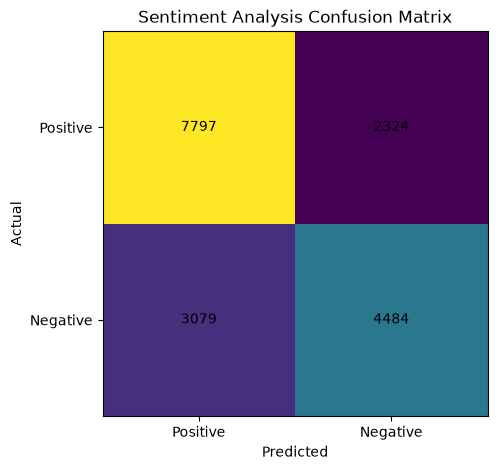

In [61]:
import matplotlib.pyplot as plt

cm = [
    [7797, 2324],
    [3079, 4484]
]

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Sentiment Analysis Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Positive", "Negative"])
plt.yticks([0, 1], ["Positive", "Negative"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

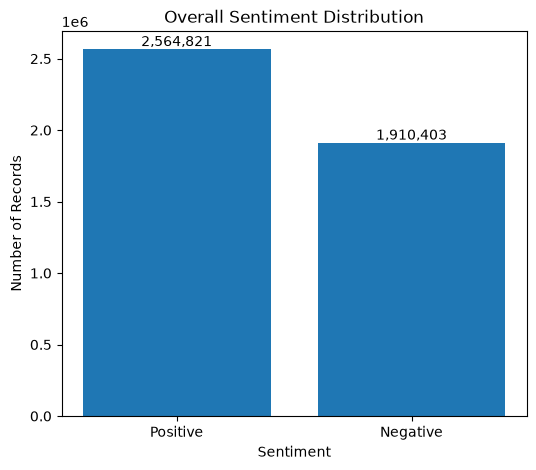

In [63]:
full_distribution = full_labeled_df.groupBy(
    "sentiment_label"
).count().toPandas()

plt.figure(figsize=(6, 5))

plt.bar(
    full_distribution["sentiment_label"],
    full_distribution["count"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")

for i, value in enumerate(full_distribution["count"]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

In [65]:
theme_sentiment = full_labeled_df.groupBy(
    "primary_theme",
    "sentiment_label"
).count()

theme_sentiment.show(20, truncate=False)

+--------------+---------------+------+
|primary_theme |sentiment_label|count |
+--------------+---------------+------+
|Technology    |Positive       |302601|
|Business      |Negative       |51581 |
|Health        |Negative       |86279 |
|Law           |Negative       |32822 |
|Investing     |Negative       |23908 |
|People        |Positive       |388960|
|Sports        |Positive       |216309|
|Law           |Positive       |25328 |
|              |Negative       |11170 |
|Environment   |Negative       |118594|
|Entertainment |Negative       |289444|
|Science       |Positive       |106012|
|Health        |Positive       |103902|
|Cryptocurrency|Negative       |54038 |
|Technology    |Negative       |174764|
|Business      |Positive       |76270 |
|Cryptocurrency|Positive       |150720|
|              |Positive       |12033 |
|People        |Negative       |349320|
|Finance       |Negative       |45121 |
+--------------+---------------+------+
only showing top 20 rows


In [67]:
from pyspark.sql.functions import when, trim, col

clean_theme_df = full_labeled_df.withColumn(
    "theme",
    when(
        col("primary_theme").isNull() | (trim(col("primary_theme")) == ""),
        "Unknown"
    ).otherwise(col("primary_theme"))
)

theme_summary = clean_theme_df.groupBy(
    "theme",
    "sentiment_label"
).count()

theme_summary.orderBy(
    col("count").desc()
).show(30, truncate=False)

+--------------+---------------+------+
|theme         |sentiment_label|count |
+--------------+---------------+------+
|Entertainment |Positive       |596215|
|People        |Positive       |388960|
|People        |Negative       |349320|
|Politics      |Negative       |332558|
|Technology    |Positive       |302601|
|Entertainment |Negative       |289444|
|Sports        |Positive       |216309|
|Technology    |Negative       |174764|
|Politics      |Positive       |161412|
|Environment   |Positive       |154461|
|Cryptocurrency|Positive       |150720|
|Sports        |Negative       |136076|
|Social        |Positive       |134796|
|Environment   |Negative       |118594|
|Science       |Positive       |106012|
|Health        |Positive       |103902|
|Social        |Negative       |88319 |
|Health        |Negative       |86279 |
|Science       |Negative       |82715 |
|Business      |Positive       |76270 |
|Cryptocurrency|Negative       |54038 |
|Finance       |Positive       |52383 |


<Figure size 1200x700 with 0 Axes>

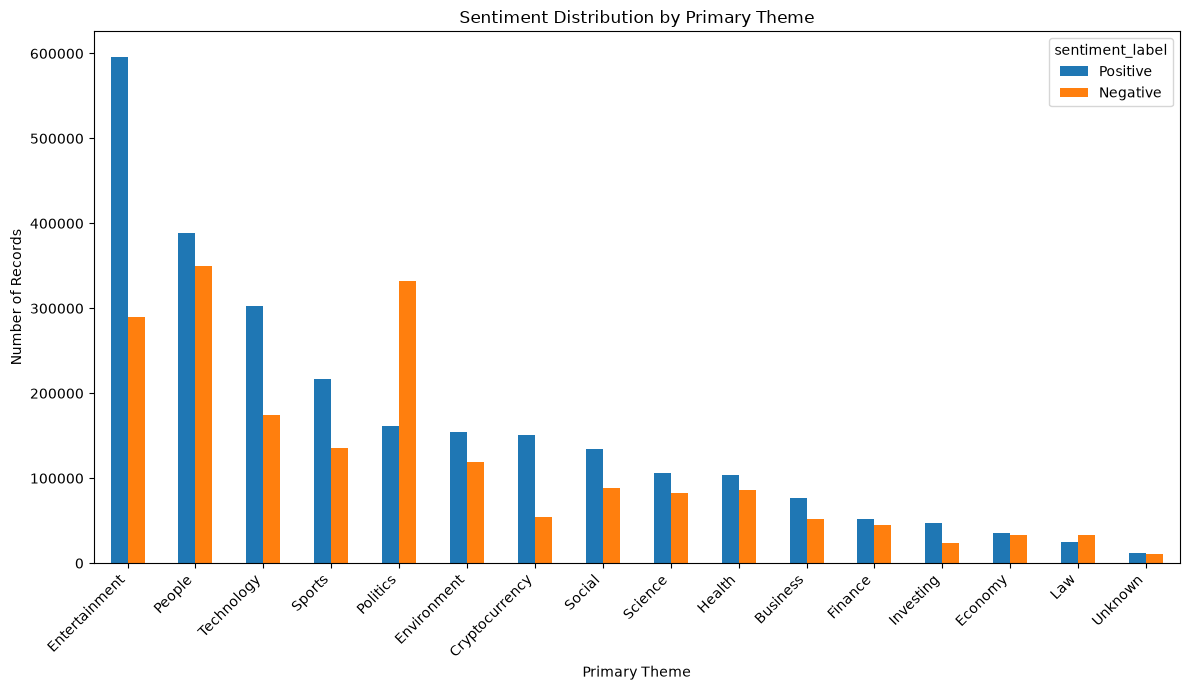

In [69]:
theme_plot = theme_summary.toPandas()

pivot_theme = theme_plot.pivot(
    index="theme",
    columns="sentiment_label",
    values="count"
).fillna(0)

pivot_theme = pivot_theme.sort_values(
    by="Positive",
    ascending=False
)

plt.figure(figsize=(12, 7))

pivot_theme[["Positive", "Negative"]].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Sentiment Distribution by Primary Theme")
plt.xlabel("Primary Theme")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

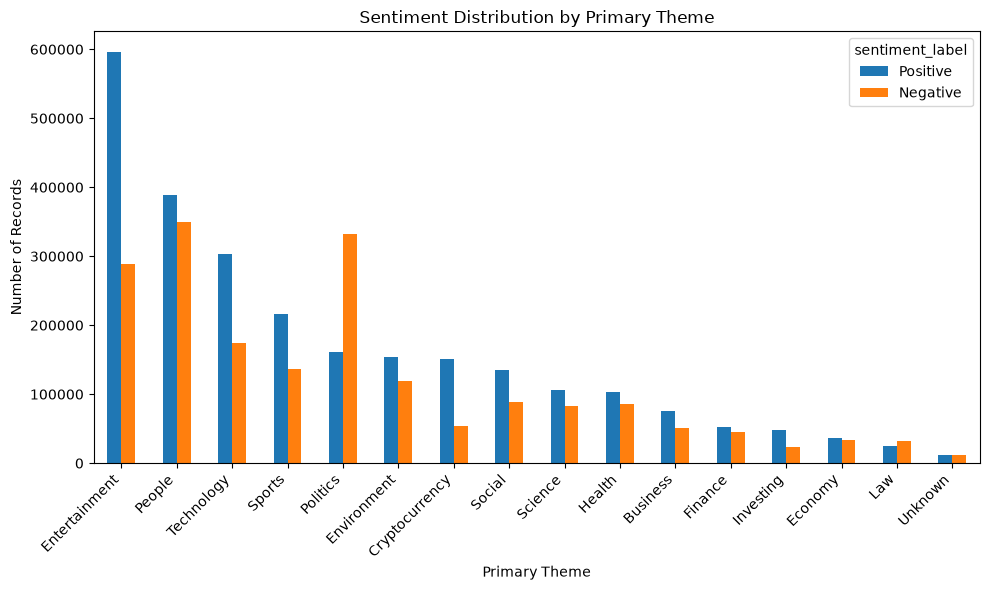

Chart saved successfully.


In [71]:
plt.figure(figsize=(10, 6))

pivot_theme[["Positive", "Negative"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Primary Theme")
plt.xlabel("Primary Theme")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "sentiment_by_theme.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

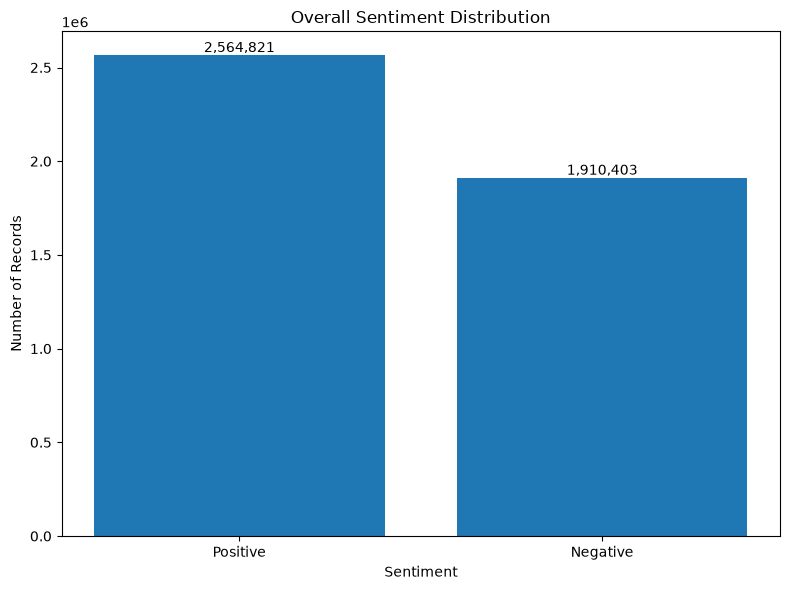

Overall sentiment chart saved successfully.


In [73]:
plt.figure(figsize=(8, 6))

plt.bar(
    full_distribution["sentiment_label"],
    full_distribution["count"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")

for i, value in enumerate(full_distribution["count"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "overall_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Overall sentiment chart saved successfully.")

In [75]:
from pyspark.sql.functions import from_json, col

stream_df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "sentiment_data") \
    .option("startingOffsets", "earliest") \
    .load()

parsed_stream_df = stream_df.select(
    from_json(
        col("value").cast("string"),
        schema
    ).alias("data")
).select("data.*")

clean_stream_df = parsed_stream_df.filter(
    col("sentiment").isNotNull()
)

print("Structured Streaming pipeline created successfully")
print("Streaming:", clean_stream_df.isStreaming)

Structured Streaming pipeline created successfully
Streaming: True


In [77]:
stream_tokenizer = Tokenizer(
    inputCol="original_text",
    outputCol="words"
)

stream_hashingTF = HashingTF(
    inputCol="words",
    outputCol="rawFeatures",
    numFeatures=10000
)

stream_features_df = stream_hashingTF.transform(
    stream_tokenizer.transform(clean_stream_df)
)

print("Streaming feature engineering created successfully")
print("Streaming:", stream_features_df.isStreaming)

Streaming feature engineering created successfully
Streaming: True


In [79]:
stream_query = stream_features_df.writeStream \
    .format("console") \
    .outputMode("append") \
    .option("truncate", False) \
    .option("numRows", 5) \
    .start()

print("Structured Streaming query started successfully")

Structured Streaming query started successfully


In [81]:
print("Streaming query active:", stream_query.isActive)
print("Status:", stream_query.status)

Streaming query active: True
Status: {'message': 'Waiting for data to arrive', 'isDataAvailable': False, 'isTriggerActive': False}


In [83]:
import json
from kafka import KafkaProducer

producer = KafkaProducer(
    bootstrap_servers="localhost:9092",
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

test_message = {
    "date": "2026-10-02T13:00:00Z",
    "original_text": "I really love this project, it is amazing!",
    "url": "test",
    "author_hash": "test_user",
    "language": "en",
    "primary_theme": "Technology",
    "english_keywords": "love, project, amazing",
    "sentiment": 0.90,
    "main_emotion": "joy",
    "secondary_themes": [1]
}

producer.send("sentiment_data", test_message).get(timeout=10)
producer.close()

print("New Kafka message sent successfully")

New Kafka message sent successfully


In [85]:
import time

time.sleep(5)

print("Streaming query active:", stream_query.isActive)
print("Recent progress:", stream_query.recentProgress)

Streaming query active: True
Recent progress: [{
    "id": "1b8d6cbc-0e0a-4492-aa10-a44a9728033b",
    "runId": "8c5fd914-6cd3-4f98-a365-c1ed307052ab",
    "name": null,
    "timestamp": "2026-10-02T12:17:32.905Z",
    "batchId": 0,
    "batchDuration": 7808,
    "numInputRows": 101,
    "inputRowsPerSecond": 0.0,
    "processedRowsPerSecond": 12.9,
    "durationMs": {
        "addBatch": 2776,
        "commitOffsets": 1304,
        "getBatch": 38,
        "latestOffset": 1642,
        "queryPlanning": 403,
        "triggerExecution": 7794,
        "walCommit": 1578
    },
    "stateOperators": [],
    "sources": [
        {
            "description": "KafkaV2[Subscribe[sentiment_data]]",
            "startOffset": null,
            "endOffset": {
                "sentiment_data": {
                    "0": 101
                }
            },
            "latestOffset": {
                "sentiment_data": {
                    "0": 101
                }
            },
            "num

In [87]:
stream_query.stop()

print("Streaming query stopped successfully")

Streaming query stopped successfully


## CONNECT PYTHON WITH MYSQL